In [102]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import box

In [103]:
DATA = Path("../data")

BLACK_BELT = DATA / "processed/black_belt_al_ms_dissolved.geojson"
PALEOMAP_CS_DIR = DATA / "raw/geology/paleomap/CS"
PALEOMAP_CM_DIR = DATA / "raw/geology/paleomap/CM"

OUT_DIR = DATA / "processed/paleocoast_frames"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DISPLAY_CRS = "EPSG:4326"
DPI = 180

In [104]:
SE_BBOX = {
    "xmin": -100.0,
    "ymin": 24.0,
    "xmax": -74.0,
    "ymax": 38.5,
}

USA_BBOX = {
    "xmin": -125.0,
    "ymin": 24.0,
    "xmax": -66.0,
    "ymax": 50.0,
}

WORLD_BBOX = {
    "xmin": -180.0,
    "ymin": -70.0,
    "xmax": 180.0,
    "ymax": 85.0,
}

In [105]:
def clip_to_lonlat_box(
    gdf: gpd.GeoDataFrame,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    bbox = gpd.GeoDataFrame(
        geometry=[box(xmin, ymin, xmax, ymax)],
        crs="EPSG:4326",
    )
    return gdf.clip(bbox)


def get_available_years(cs_dir: Path) -> list[int]:
    years = []
    pattern = re.compile(r"^(\d+)Ma_CS_v7\.shp$")
    for p in cs_dir.glob("*.shp"):
        m = pattern.match(p.name)
        if m:
            years.append(int(m.group(1)))
    return sorted(years, reverse=True)  # 535, 525, ... , 0


def load_cs_cm_for_year(year: int):
    cs = gpd.read_file(PALEOMAP_CS_DIR / f"{year}Ma_CS_v7.shp").to_crs(DISPLAY_CRS)
    cm = gpd.read_file(PALEOMAP_CM_DIR / f"{year}Ma_CM_v7.shp").to_crs(DISPLAY_CRS)
    return cs, cm


def dissolve_clip(gdf: gpd.GeoDataFrame, bbox: dict):
    gdf_clip = clip_to_lonlat_box(gdf, **bbox)
    geom = gdf_clip.union_all()
    return gdf_clip, geom


def build_band(cm_geom, cs_geom):
    return cm_geom.difference(cs_geom)

In [106]:
black_belt = gpd.read_file(BLACK_BELT).to_crs(DISPLAY_CRS)

In [107]:
years = get_available_years(PALEOMAP_CS_DIR)
years[:20], years[-10:]

([535,
  525,
  515,
  510,
  505,
  500,
  495,
  490,
  485,
  480,
  475,
  470,
  465,
  455,
  450,
  445,
  440,
  435,
  430,
  425],
 [45, 40, 35, 30, 25, 20, 15, 10, 5, 0])

In [108]:
YEAR = 70

cs, cm = load_cs_cm_for_year(YEAR)

cs_se, cs_se_geom = dissolve_clip(cs, SE_BBOX)
cm_se, cm_se_geom = dissolve_clip(cm, SE_BBOX)
band_se_geom = build_band(cm_se_geom, cs_se_geom)

cs_usa, cs_usa_geom = dissolve_clip(cs, USA_BBOX)
cm_usa, cm_usa_geom = dissolve_clip(cm, USA_BBOX)
band_usa_geom = build_band(cm_usa_geom, cs_usa_geom)

cs_world, cs_world_geom = dissolve_clip(cs, WORLD_BBOX)
cm_world, cm_world_geom = dissolve_clip(cm, WORLD_BBOX)
band_world_geom = build_band(cm_world_geom, cs_world_geom)

In [109]:
def match_panel_aspect_y(xmin, xmax, world_bbox):
    """
    Given a desired x-range for the left panel, expand the y-range so that
    the panel aspect ratio matches the world panel aspect ratio.
    """
    world_width = world_bbox["xmax"] - world_bbox["xmin"]
    world_height = world_bbox["ymax"] - world_bbox["ymin"]
    target_ratio = world_height / world_width

    width = xmax - xmin
    target_height = width * target_ratio
    return target_height

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


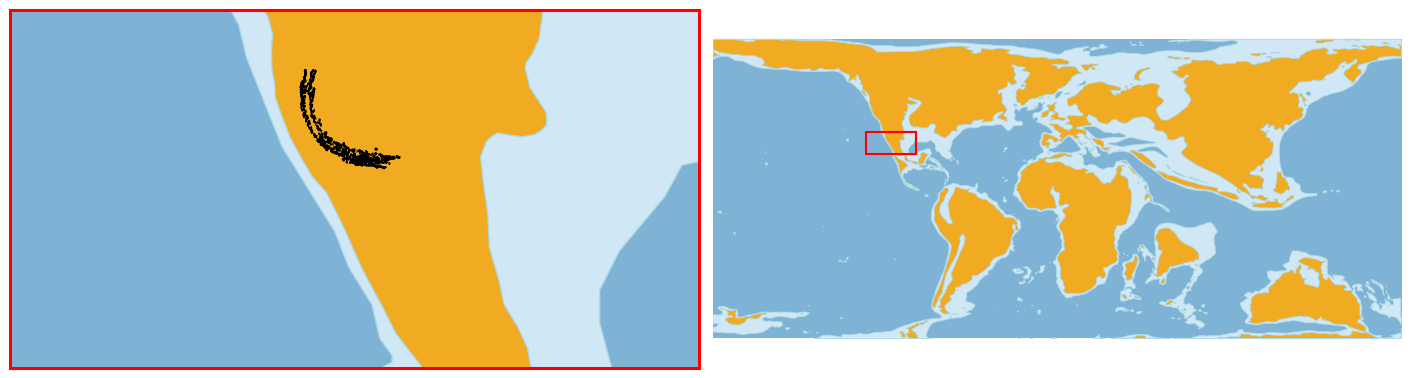

In [110]:
from matplotlib.patches import Rectangle
import geopandas as gpd
import matplotlib.pyplot as plt

def match_panel_aspect_y(xmin, xmax, world_bbox):
    world_width = world_bbox["xmax"] - world_bbox["xmin"]
    world_height = world_bbox["ymax"] - world_bbox["ymin"]
    target_ratio = world_height / world_width
    width = xmax - xmin
    return width * target_ratio

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 1]},
)

OCEAN_COLOR = "#7fb3d5"
CM_COLOR = "#bcdff1"
BAND_COLOR = "#d6ecf7"
LAND_COLOR = "orange"
BOX_COLOR = "red"

# ------------------------------------------------------------------
# Precompute left-panel extent so patch + limits + red box all agree
# ------------------------------------------------------------------
se_xmin = SE_BBOX["xmin"]
se_xmax = SE_BBOX["xmax"]
y_center = 0.5 * (SE_BBOX["ymin"] + SE_BBOX["ymax"])
target_height = match_panel_aspect_y(se_xmin, se_xmax, WORLD_BBOX)

se_ymin = y_center - 0.5 * target_height
se_ymax = y_center + 0.5 * target_height

# -------------------------
# Left: Southeast zoom
# -------------------------
ax = axes[0]

# ocean background
ax.add_patch(
    Rectangle(
        (se_xmin, se_ymin),
        se_xmax - se_xmin,
        se_ymax - se_ymin,
        facecolor=OCEAN_COLOR,
        edgecolor="none",
        zorder=0,
    )
)

gpd.GeoDataFrame(geometry=[cm_se_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=CM_COLOR, edgecolor="none", alpha=0.6, zorder=1
)
gpd.GeoDataFrame(geometry=[band_se_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=BAND_COLOR, edgecolor="none", alpha=0.9, zorder=2
)
gpd.GeoDataFrame(geometry=[cs_se_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=LAND_COLOR, edgecolor="none", alpha=0.85, zorder=3
)

gpd.GeoDataFrame(geometry=[cs_se_geom], crs=DISPLAY_CRS).boundary.plot(
    ax=ax, color="lightblue", linewidth=1.0, zorder=4
)
gpd.GeoDataFrame(geometry=[cm_se_geom], crs=DISPLAY_CRS).boundary.plot(
    ax=ax, color="lightblue", linewidth=1.0, zorder=4
)

black_belt.boundary.plot(
    ax=ax, color="black", linewidth=1.2, linestyle="--", zorder=5
)

ax.set_xlim(se_xmin, se_xmax)
ax.set_ylim(se_ymin, se_ymax)

# remove all axis furniture
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# explicit red frame in axes coordinates, always on top
ax.add_patch(
    Rectangle(
        (0, 0), 1, 1,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor=BOX_COLOR,
        linewidth=2.2,
        zorder=100,
        clip_on=False,
    )
)

# -------------------------
# Right: World context
# -------------------------
ax = axes[1]

ax.add_patch(
    Rectangle(
        (WORLD_BBOX["xmin"], WORLD_BBOX["ymin"]),
        WORLD_BBOX["xmax"] - WORLD_BBOX["xmin"],
        WORLD_BBOX["ymax"] - WORLD_BBOX["ymin"],
        facecolor=OCEAN_COLOR,
        edgecolor="none",
        zorder=0,
    )
)

gpd.GeoDataFrame(geometry=[cm_world_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=CM_COLOR, edgecolor="none", alpha=0.6, zorder=1
)
gpd.GeoDataFrame(geometry=[band_world_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=BAND_COLOR, edgecolor="none", alpha=0.9, zorder=2
)
gpd.GeoDataFrame(geometry=[cs_world_geom], crs=DISPLAY_CRS).plot(
    ax=ax, color=LAND_COLOR, edgecolor="none", alpha=0.85, zorder=3
)

gpd.GeoDataFrame(geometry=[cs_world_geom], crs=DISPLAY_CRS).boundary.plot(
    ax=ax, color="lightblue", linewidth=0.6, zorder=4
)
gpd.GeoDataFrame(geometry=[cm_world_geom], crs=DISPLAY_CRS).boundary.plot(
    ax=ax, color="lightblue", linewidth=0.6, zorder=4
)

# red box showing the left-panel extent
ax.add_patch(
    Rectangle(
        (se_xmin, se_ymin),
        se_xmax - se_xmin,
        se_ymax - se_ymin,
        facecolor="none",
        edgecolor=BOX_COLOR,
        linewidth=1.5,
        zorder=6,
    )
)

ax.set_xlim(WORLD_BBOX["xmin"], WORLD_BBOX["xmax"])
ax.set_ylim(WORLD_BBOX["ymin"], WORLD_BBOX["ymax"])

ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# force both panels to have the same physical box height/shape
for ax in axes:
    ax.set_box_aspect(0.52)

plt.show()

In [112]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

OUT_ROOT = Path("../data/processed/paleo_frames")
OUT_GLOBAL = OUT_ROOT / "global"
OUT_BLACKBELT = OUT_ROOT / "blackbelt"

OUT_GLOBAL.mkdir(parents=True, exist_ok=True)
OUT_BLACKBELT.mkdir(parents=True, exist_ok=True)

OCEAN_COLOR = "#7fb3d5"
CM_COLOR = "#bcdff1"
BAND_COLOR = "#d6ecf7"
LAND_COLOR = "orange"


def geom_gdf(geom, crs):
    return gpd.GeoDataFrame(geometry=[geom], crs=crs)


def is_valid_nonempty_geom(geom):
    return geom is not None and (not geom.is_empty)


def safe_plot_polygon(ax, geom, crs, color, alpha=1.0, zorder=1):
    if is_valid_nonempty_geom(geom):
        geom_gdf(geom, crs).plot(
            ax=ax,
            color=color,
            edgecolor="none",
            alpha=alpha,
            zorder=zorder,
            aspect=1,   # disable geopandas auto-aspect logic
        )


def safe_plot_boundary(ax, geom, crs, color, linewidth=1.0, linestyle="-", zorder=1):
    if is_valid_nonempty_geom(geom):
        geom_gdf(geom, crs).boundary.plot(
            ax=ax,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=zorder,
            aspect=1,   # disable geopandas auto-aspect logic
        )


def save_blackbelt_frame(year):
    cs, cm = load_cs_cm_for_year(year)

    _, cs_se_geom = dissolve_clip(cs, SE_BBOX)
    _, cm_se_geom = dissolve_clip(cm, SE_BBOX)

    band_se_geom = build_band(cm_se_geom, cs_se_geom)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    ax.add_patch(
        Rectangle(
            (SE_BBOX["xmin"], SE_BBOX["ymin"]),
            SE_BBOX["xmax"] - SE_BBOX["xmin"],
            SE_BBOX["ymax"] - SE_BBOX["ymin"],
            facecolor=OCEAN_COLOR,
            edgecolor="none",
            zorder=0,
        )
    )

    safe_plot_polygon(ax, cm_se_geom, DISPLAY_CRS, CM_COLOR, alpha=1.0, zorder=1)
    safe_plot_polygon(ax, band_se_geom, DISPLAY_CRS, BAND_COLOR, alpha=1.0, zorder=2)
    safe_plot_polygon(ax, cs_se_geom, DISPLAY_CRS, LAND_COLOR, alpha=1.0, zorder=3)

    safe_plot_boundary(ax, cs_se_geom, DISPLAY_CRS, "lightblue", linewidth=1.0, zorder=4)
    safe_plot_boundary(ax, cm_se_geom, DISPLAY_CRS, "lightblue", linewidth=1.0, zorder=4)

    black_belt.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2,
        linestyle="--",
        zorder=5,
        aspect=1,
    )

    ax.set_xlim(SE_BBOX["xmin"], SE_BBOX["xmax"])
    ax.set_ylim(SE_BBOX["ymin"], SE_BBOX["ymax"])
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax.add_patch(
        Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            facecolor="none",
            edgecolor="red",
            linewidth=2,
            clip_on=False,
            zorder=100,
        )
    )

    save_path = OUT_BLACKBELT / f"blackbelt_{year:03d}Ma.png"
    fig.savefig(save_path, bbox_inches="tight", pad_inches=0, transparent=False)
    plt.close(fig)


def save_global_frame(year):
    cs, cm = load_cs_cm_for_year(year)

    _, cs_world_geom = dissolve_clip(cs, WORLD_BBOX)
    _, cm_world_geom = dissolve_clip(cm, WORLD_BBOX)

    band_world_geom = build_band(cm_world_geom, cs_world_geom)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

    ax.add_patch(
        Rectangle(
            (WORLD_BBOX["xmin"], WORLD_BBOX["ymin"]),
            WORLD_BBOX["xmax"] - WORLD_BBOX["xmin"],
            WORLD_BBOX["ymax"] - WORLD_BBOX["ymin"],
            facecolor=OCEAN_COLOR,
            edgecolor="none",
            zorder=0,
        )
    )

    safe_plot_polygon(ax, cm_world_geom, DISPLAY_CRS, CM_COLOR, alpha=1.0, zorder=1)
    safe_plot_polygon(ax, band_world_geom, DISPLAY_CRS, BAND_COLOR, alpha=1.0, zorder=2)
    safe_plot_polygon(ax, cs_world_geom, DISPLAY_CRS, LAND_COLOR, alpha=1.0, zorder=3)

    ax.add_patch(
        Rectangle(
            (SE_BBOX["xmin"], SE_BBOX["ymin"]),
            SE_BBOX["xmax"] - SE_BBOX["xmin"],
            SE_BBOX["ymax"] - SE_BBOX["ymin"],
            facecolor="none",
            edgecolor="red",
            linewidth=1.2,
            zorder=10,
        )
    )

    ax.set_xlim(WORLD_BBOX["xmin"], WORLD_BBOX["xmax"])
    ax.set_ylim(WORLD_BBOX["ymin"], WORLD_BBOX["ymax"])
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    save_path = OUT_GLOBAL / f"global_{year:03d}Ma.png"
    fig.savefig(save_path, bbox_inches="tight", pad_inches=0, transparent=False)
    plt.close(fig)


years = [y for y in get_available_years(PALEOMAP_CS_DIR) if 0 <= y <= 120]

for year in years:
    print("Exporting", year)
    try:
        save_global_frame(year)
        save_blackbelt_frame(year)
    except Exception as e:
        print(f"  Failed for {year} Ma: {e}")

print("Done.")

Exporting 120
Exporting 105
Exporting 95
Exporting 90
Exporting 85
Exporting 80
Exporting 70
Exporting 65
Exporting 60
Exporting 50
Exporting 45
Exporting 40
Exporting 35
Exporting 30
Exporting 25
Exporting 20
Exporting 15
Exporting 10
Exporting 5
Exporting 0
Done.
